In [2]:
import numpy as np
import itertools

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
trials = [1]
conditions = list(itertools.product(C_H_list, P_CO_list))
E_grid_SHE = np.linspace(0.5, 1.0, 100)
experiments_mean = {}
nan_array = np.full_like(E_grid_SHE, np.nan)
nan_matrix = np.full((len(trials), len(E_grid_SHE)), np.nan)

for condition in conditions:
    C_H, P_CO = condition
    experiments_mean[(C_H, P_CO)] = {
            'truncated_E': E_grid_SHE,
            'truncated_rate': nan_array.copy(),
            'truncated_rate_SD': nan_array.copy(),
            'truncated_log_rate': nan_array.copy(),
            'truncated_log_rate_SD': nan_array.copy(),
            'truncated_rate_matrix': nan_matrix.copy(),
            'E': E_grid_SHE,
            'rate': nan_array.copy(),
            'rate_SD': nan_array.copy(),
            'log_rate': nan_array.copy(),
            'log_rate_SD': nan_array.copy(),
            'alpha': nan_array.copy(),
            'alpha_SD': nan_array.copy(),
            'E_H': E_grid_SHE, 
            'delta_H': nan_array.copy(), 
            'delta_H_SD': nan_array.copy(),
            'E_CO': E_grid_SHE,
            'delta_CO': nan_array.copy(), 
            'delta_CO_SD': nan_array.copy()
        }

In [3]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h 
from _CO_Oxidation import wrapper_acid as wp
from _CO_Oxidation.wrapper_acid import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = experiments_mean
wp.process_experimental_data(experiments_data, C_H_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_H_in = wp.C_H_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Sampling: [exponent, rate]


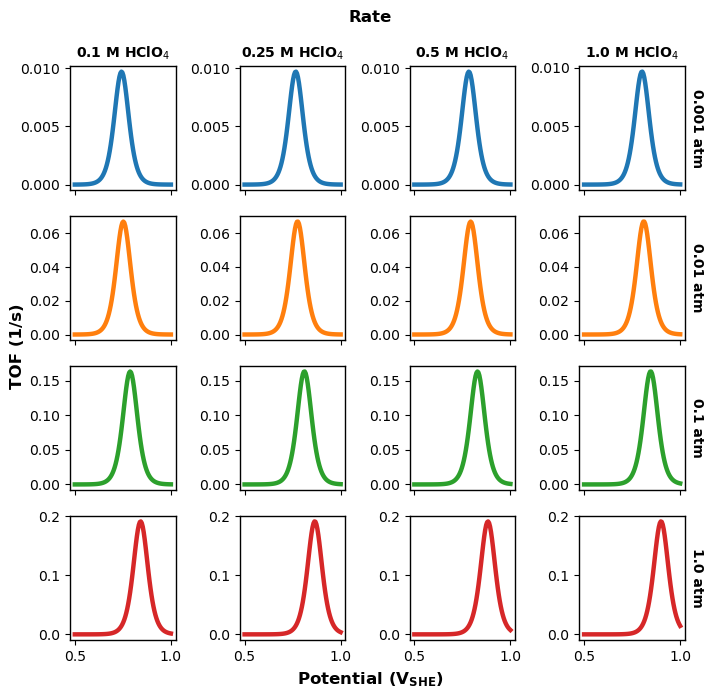

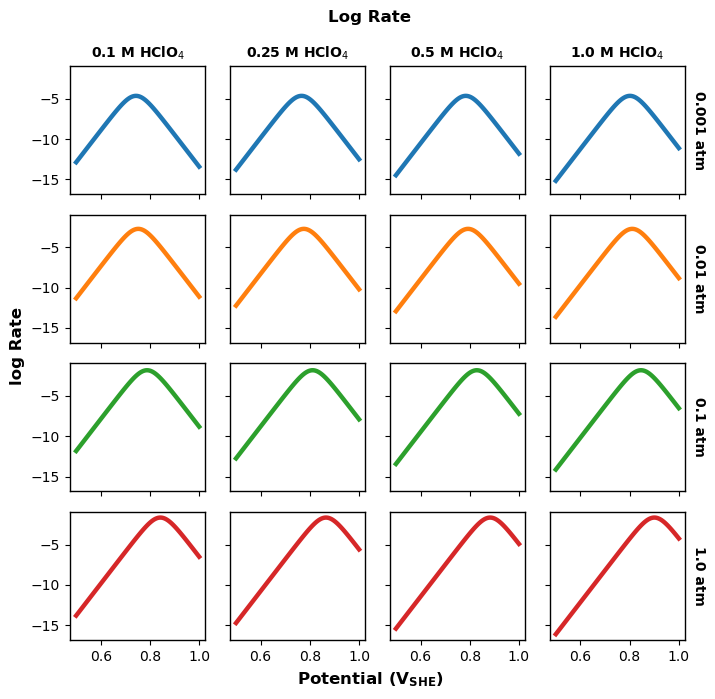

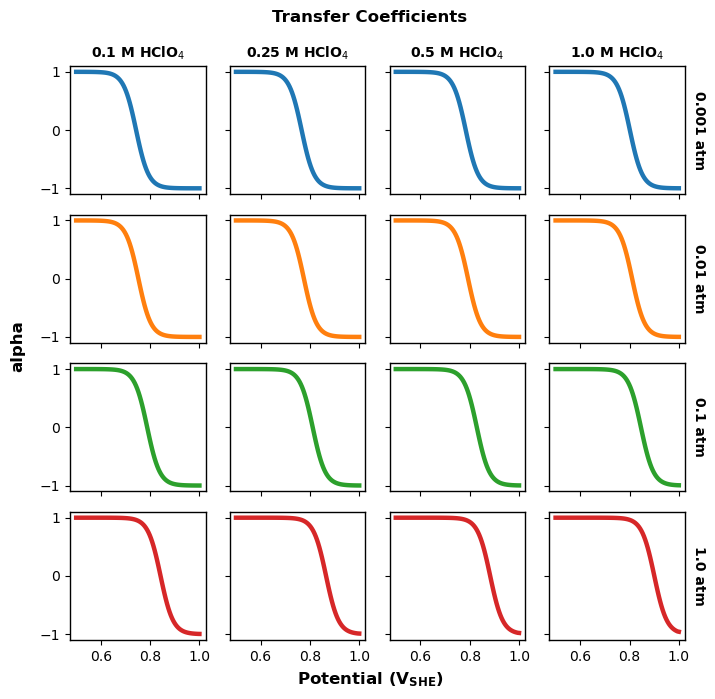

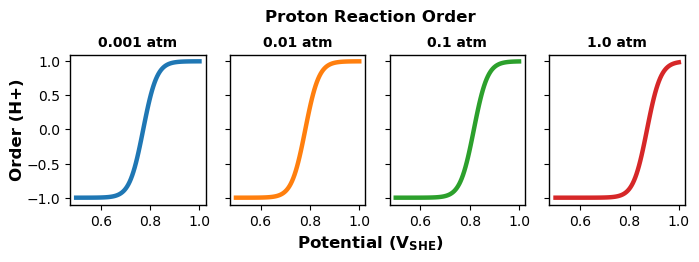

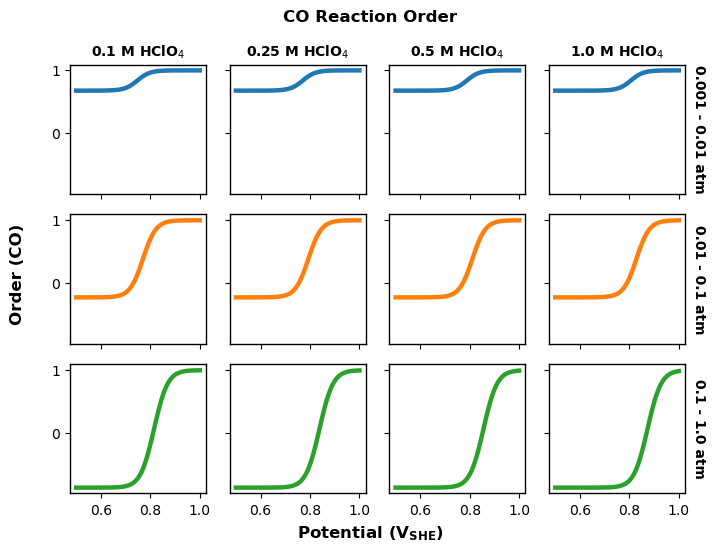

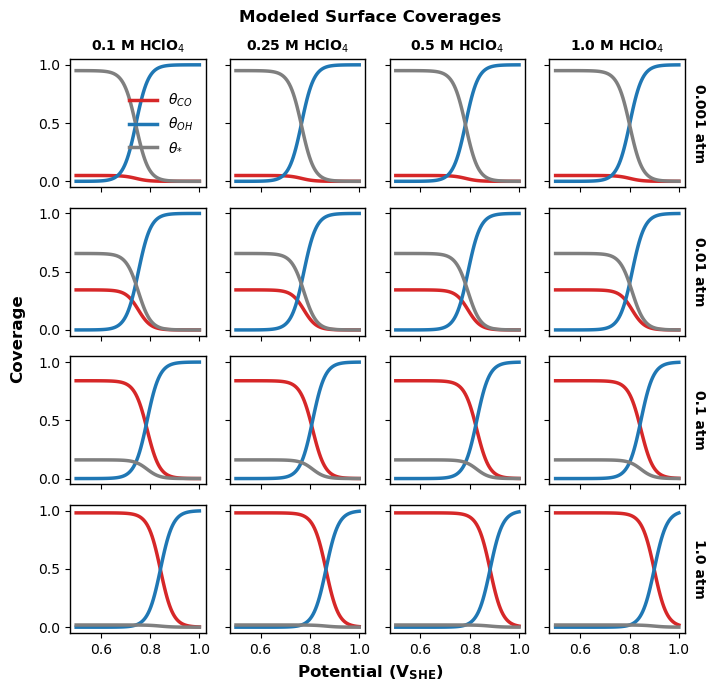

In [17]:
def observables_sim(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = 0
    sigma_base = 0
    exponent = pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    
    # FIX: Use zeros to prevent PyMC from triggering Imputation and renaming our variable
    dummy_obs = np.zeros(np.shape(wp.rate_obs_matrix)) 
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=dummy_obs)
    return rate

with pm.Model() as LH_2_sim:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors forced to exact numbers for simulation
    deltaG1_0 = -0.1
    deltaG4_0 = 0.8
    Gact2_0 = 0.75

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    
    # Use the simulation observables (with zeros)
    rate = observables_sim(log_rate) 

with LH_2_sim:
    # No more ImputationWarning!
    trace_sim = pm.sample_prior_predictive(samples=100)

# Copy groups over so the wrapper can find them
trace_sim.add_groups(posterior=trace_sim.prior)
trace_sim.add_groups(posterior_predictive=trace_sim.prior_predictive)
trace_sim = wp.add_post_sampling_observables(trace_sim)

# Plot!
plot_model_fits(trace_sim, trace_sim) 
plot_coverages(trace_sim)

Sampling: [exponent, rate]


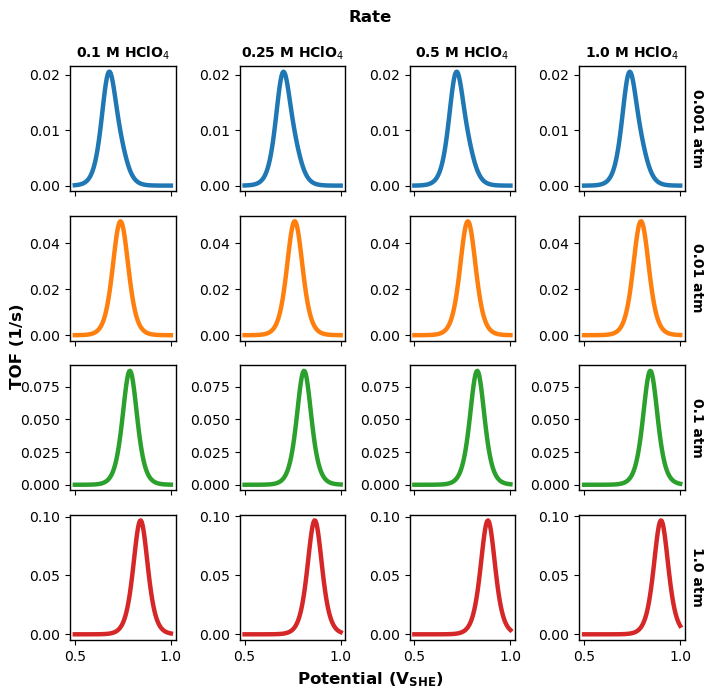

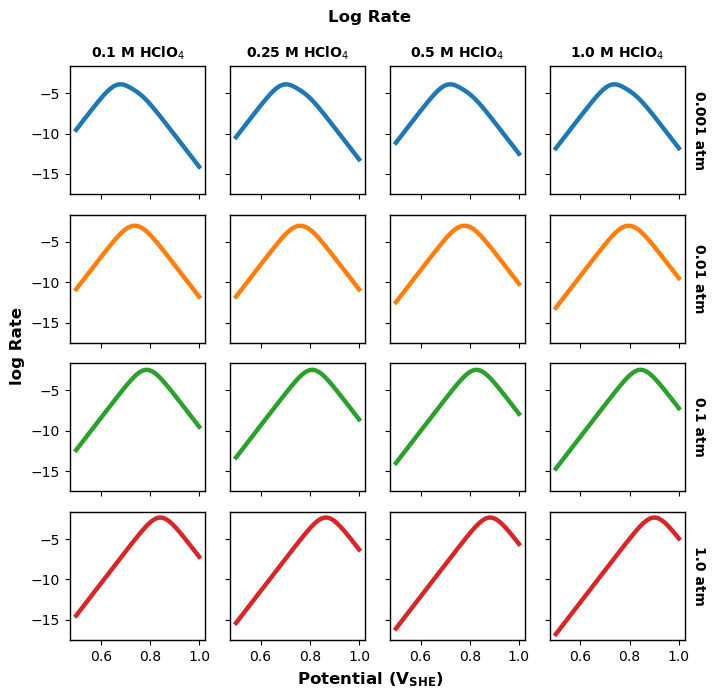

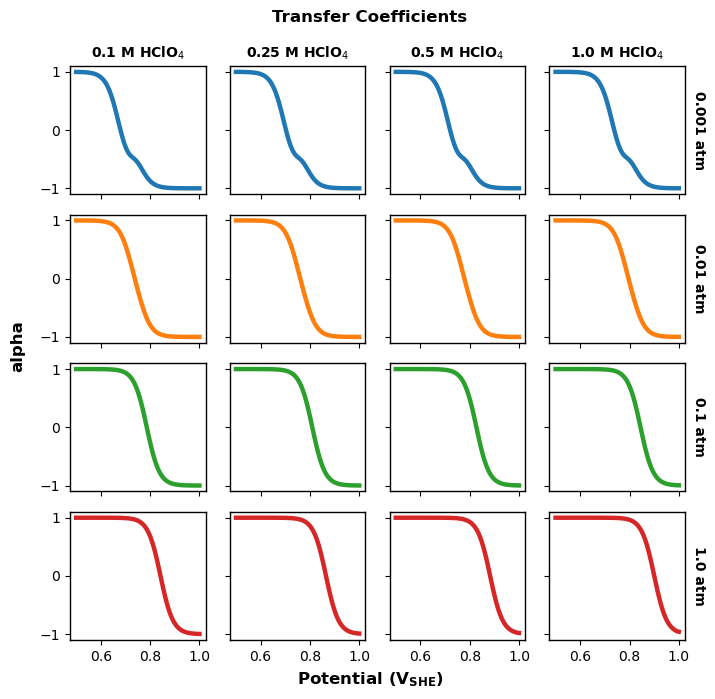

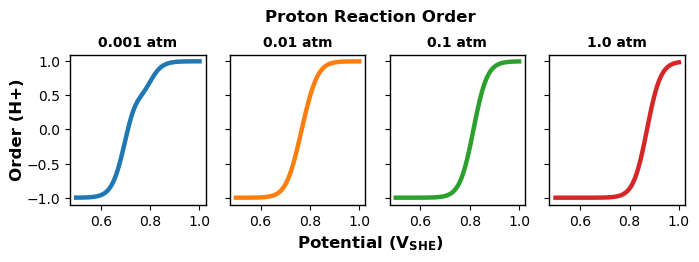

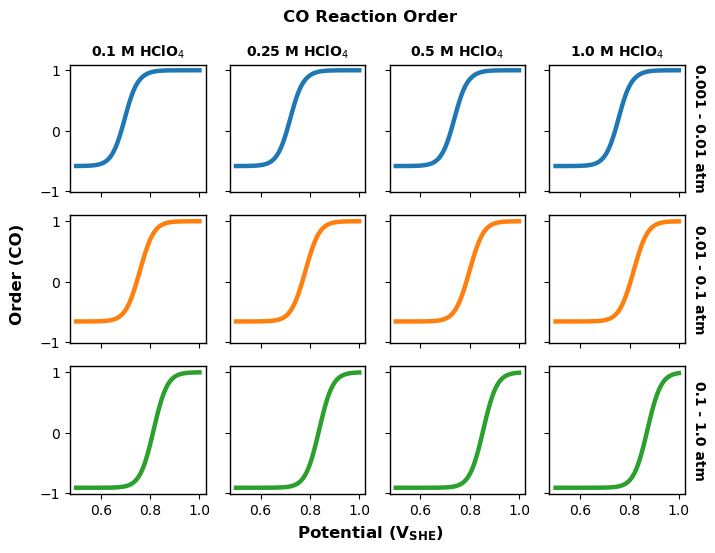

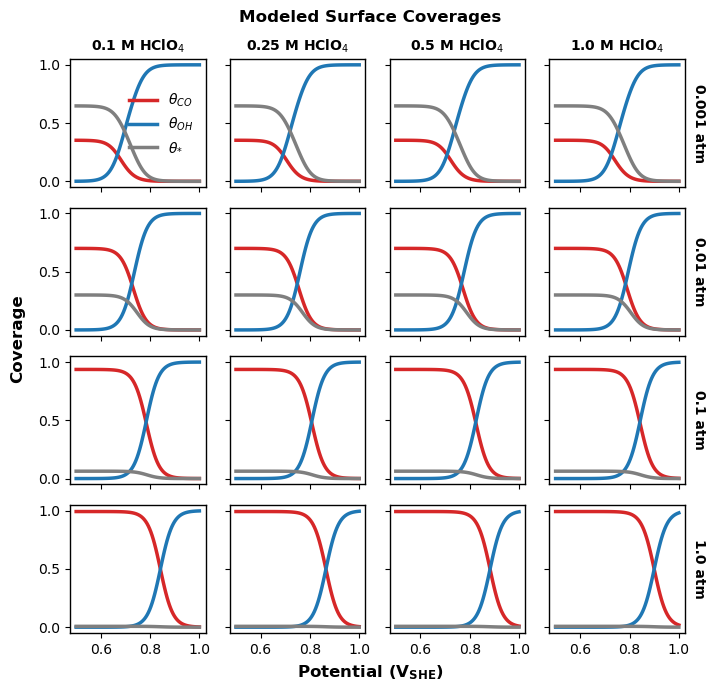

In [24]:
with pm.Model() as LH_3_sim:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    * Simulated over 3 independent sites in equal fractions.
    '''
    # Define the 3 sets of sites: (deltaG1_0, deltaG4_0, Gact2_0)
    sites = [
            (-0.1, 0.8, 0.75),  # Site 1: Strong binding
            (-0.15, 0.75, 0.8),  # Site 2: Medium binding (baseline)
            (-0.2, 0.7, 0.775)   # Site 3: Weak binding
        ]
    
    log_rates_list = []
    log_theta_CO_list = []
    log_theta_OH_list = []
    log_theta_empty_list = []
    
    # Loop over the 3 sites to generate their independent thermodynamics
    for i, (dG1_val, dG4_val, Gact_val) in enumerate(sites):
        # We define them as deterministics just in case the sampler needs to track them
        deltaG1_0 = pm.Deterministic(f'deltaG1_0_{i}', pt.as_tensor_variable(dG1_val))
        deltaG4_0 = pm.Deterministic(f'deltaG4_0_{i}', pt.as_tensor_variable(dG4_val))
        Gact2_0 = pm.Deterministic(f'Gact2_0_{i}', pt.as_tensor_variable(Gact_val))
        
        # Site-specific thermodynamics
        deltaG4 = deltaG4_0 - E_in
        log_K1 = -deltaG1_0/(kb_eV*T)
        log_K4 = -deltaG4/(kb_eV*T)
        log_k2 = np.log(kb_J*T/h) - Gact2_0/(kb_eV*T)
        
        # Site-specific isotherms
        term_CO = log_K1 + np.log(P_CO_in)
        term_OH = log_K4 - np.log(C_H_in)
        zeros = pt.zeros_like(term_CO)
        
        log_theta = -pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
        log_theta_CO = term_CO + log_theta
        log_theta_OH = term_OH + log_theta
        
        # Store for averaging
        log_theta_CO_list.append(log_theta_CO)
        log_theta_OH_list.append(log_theta_OH)
        log_theta_empty_list.append(log_theta)
        log_rates_list.append(log_k2 + log_theta_CO + log_theta_OH)

    # --- AGGREGATE THE SITES ---
    # To average 3 items in log-space: log( (A + B + C)/3 ) = logsumexp(logA, logB, logC) - log(3)
    log_rate_total = pt.logsumexp(pt.stack(log_rates_list), axis=0) - np.log(3.0)
    
    # Define the aggregated coverages so your plot_coverages wrapper works smoothly
    theta_CO = pm.Deterministic('theta_CO', pt.exp(pt.logsumexp(pt.stack(log_theta_CO_list), axis=0) - np.log(3.0)))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(pt.logsumexp(pt.stack(log_theta_OH_list), axis=0) - np.log(3.0)))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(pt.logsumexp(pt.stack(log_theta_empty_list), axis=0) - np.log(3.0)))
    
    # Use the simulation observables (with dummy zeros) on the aggregated rate
    rate = observables_sim(log_rate_total) 

# Run the predictive check exactly as before
with LH_3_sim:
    trace_sim = pm.sample_prior_predictive(samples=100)

trace_sim.add_groups(posterior=trace_sim.prior)
trace_sim.add_groups(posterior_predictive=trace_sim.prior_predictive)
trace_sim = wp.add_post_sampling_observables(trace_sim)

plot_model_fits(trace_sim, trace_sim) 
plot_coverages(trace_sim)